<a href="https://colab.research.google.com/github/rounak393/clab/blob/main/moddcsamhmam.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import os
os.environ["KAGGLE_API_TOKEN"]='KGAT_c03d989b55c966d18c971a92b023645b'

In [2]:
!kaggle datasets download -d britikak/busi-dataset

Dataset URL: https://www.kaggle.com/datasets/britikak/busi-dataset
License(s): unknown
100% 195M/195M [00:02<00:00, 100MB/s] 



In [3]:
!unzip -q busi-dataset.zip -d busi_dataset

In [4]:
!pip install albumentations optuna -q

import os
import copy
import torch
import random
import numpy as np
import torch.nn as nn
import torch.nn.functional as F
import torchvision.models as models
from torch.utils.data import Dataset, DataLoader, Subset
from PIL import Image
import albumentations as A
from tqdm import tqdm
import optuna

torch.backends.cudnn.benchmark = True
torch.manual_seed(999)
random.seed(999)
np.random.seed(999)

BASE_DIR = "/content/busi_dataset/Dataset_BUSI_with_GT"
CLASSES = ["benign", "malignant"]
IMG_SIZE = 256
BATCH_SIZE = 4
FULL_EPOCHS = 100
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")


train_transform = A.Compose([
    A.Resize(IMG_SIZE, IMG_SIZE),
    A.HorizontalFlip(p=0.5),
    A.VerticalFlip(p=0.5),
    A.ShiftScaleRotate(shift_limit=0.1, scale_limit=0.1, rotate_limit=15, p=0.5),
    A.GaussianBlur(blur_limit=(3, 7), sigma_limit=0.5, p=0.5),
    A.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225))
])

val_transform = A.Compose([
    A.Resize(IMG_SIZE, IMG_SIZE),
    A.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225))
])


class BUSISegmentationDataset(Dataset):
    def __init__(self, base_dir, classes, transform=None):
        self.samples = []
        self.transform = transform
        for cls in classes:
            cls_dir = os.path.join(base_dir, cls)
            if not os.path.exists(cls_dir): continue
            images = [f for f in os.listdir(cls_dir) if f.endswith(".png") and "_mask" not in f]
            for img_name in images:
                img_path = os.path.join(cls_dir, img_name)
                base_name = img_name.replace(".png", "")
                mask_files = [f for f in os.listdir(cls_dir) if f.startswith(base_name + "_mask") and f.endswith(".png")]
                if not mask_files: continue
                self.samples.append((img_path, [os.path.join(cls_dir, f) for f in mask_files]))

    def __len__(self): return len(self.samples)

    def __getitem__(self, idx):
        img_path, mask_paths = self.samples[idx]
        image = np.array(Image.open(img_path).convert("RGB"))

        combined_mask = np.zeros(image.shape[:2], dtype=np.uint8)
        for mpath in mask_paths:
            mask = np.array(Image.open(mpath).convert("L"))
            combined_mask = np.logical_or(combined_mask, (mask > 0).astype(np.uint8))
        combined_mask = combined_mask.astype(np.float32)

        if self.transform:
            augmented = self.transform(image=image, mask=combined_mask)
            image, combined_mask = augmented["image"], augmented["mask"]

        return torch.from_numpy(image).permute(2, 0, 1).float(), torch.from_numpy(combined_mask).unsqueeze(0).float()

full_dataset = BUSISegmentationDataset(BASE_DIR, classes=CLASSES, transform=None)
indices = list(range(len(full_dataset)))
np.random.shuffle(indices)

train_size, val_size = int(0.8 * len(full_dataset)), int(0.1 * len(full_dataset))
train_dataset = Subset(BUSISegmentationDataset(BASE_DIR, CLASSES, transform=train_transform), indices[val_size:train_size + val_size])
val_dataset = Subset(BUSISegmentationDataset(BASE_DIR, CLASSES, transform=val_transform), indices[:val_size])
test_dataset = Subset(BUSISegmentationDataset(BASE_DIR, CLASSES, transform=val_transform), indices[train_size + val_size:])

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=2, pin_memory=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 419.5/419.5 kB 12.8 MB/s eta 0:00:00


/usr/local/lib/python3.12/dist-packages/albumentations/core/validation.py:114: UserWarning: ShiftScaleRotate is a special case of Affine transform. Please use Affine transform instead.
  original_init(self, **validated_kwargs)


In [5]:
class DoubleConv(nn.Module):
    def __init__(self, in_channels, out_channels):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=1),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_channels, out_channels, kernel_size=3, padding=1),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True)
        )
    def forward(self, x): return self.net(x)

class DualChannelAttention(nn.Module):
    def __init__(self, channels, reduction=8):
        super().__init__()
        self.avg_pool = nn.AdaptiveAvgPool2d(1)
        self.max_pool = nn.AdaptiveMaxPool2d(1)

        inter_channels = max(channels // reduction, 4)
        self.mlp = nn.Sequential(
            nn.Conv2d(channels, inter_channels, 1, bias=False),
            nn.ReLU(inplace=True),
            nn.Conv2d(inter_channels, channels, 1, bias=False)
        )
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        avg_out = self.mlp(self.avg_pool(x))
        max_out = self.mlp(self.max_pool(x))
        return self.sigmoid(avg_out + max_out)

class DCSAM(nn.Module):
    def __init__(self, channels):
        super().__init__()
        self.smooth = nn.AvgPool2d(3, stride=1, padding=1)
        self.ca = DualChannelAttention(channels)
        self.sa = nn.Sequential(nn.Conv2d(2, 1, 7, padding=3, bias=False), nn.Sigmoid())

    def forward(self, x):
        details = x - self.smooth(x)
        x = x + details
        x = x * self.ca(x)
        sa_in = torch.cat([torch.mean(x, dim=1, keepdim=True), torch.max(x, dim=1, keepdim=True)[0]], dim=1)
        return x * self.sa(sa_in)

class HMAM(nn.Module):
    def __init__(self, channels):
        super().__init__()
        inter = channels // 4
        self.reduce = nn.Conv2d(channels, inter * 3, 1, bias=False)
        self.d1 = nn.Conv2d(inter, inter, 3, padding=1, dilation=1, bias=False)
        self.d3 = nn.Conv2d(inter, inter, 3, padding=3, dilation=3, bias=False)
        self.d5 = nn.Conv2d(inter, inter, 3, padding=5, dilation=5, bias=False)

        self.pool = nn.AdaptiveAvgPool2d(1)
        self.pool_conv = nn.Conv2d(channels, inter, 1, bias=False)
        self.fuse = nn.Conv2d(inter * 4, channels, 1, bias=False)
        self.se = DualChannelAttention(channels)

    def forward(self, x):
        b1, b2, b3 = torch.split(self.reduce(x), x.shape[1] // 4, dim=1)
        b1, b2, b3 = self.d1(b1), self.d3(b2), self.d5(b3)
        b4 = F.interpolate(self.pool_conv(self.pool(x)), size=x.shape[2:], mode='bilinear', align_corners=False)
        fused = self.fuse(torch.cat([b1, b2, b3, b4], dim=1))
        return fused * self.se(fused)


class ResNet50HMUNet(nn.Module):
    def __init__(self, out_channels=1):
        super().__init__()
        resnet = models.resnet50(weights=models.ResNet50_Weights.DEFAULT)

        self.e1 = nn.Sequential(resnet.conv1, resnet.bn1, resnet.relu)
        self.maxpool = resnet.maxpool
        self.e2 = resnet.layer1
        self.e3 = resnet.layer2
        self.e4 = resnet.layer3

        self.bottleneck = resnet.layer4
        self.hmam = HMAM(2048)

        self.dcsam1 = DCSAM(64)
        self.dcsam2 = DCSAM(256)

        self.up4 = nn.ConvTranspose2d(2048, 1024, kernel_size=2, stride=2)
        self.dec4 = DoubleConv(2048, 1024)
        self.up3 = nn.ConvTranspose2d(1024, 512, kernel_size=2, stride=2)
        self.dec3 = DoubleConv(1024, 512)
        self.up2 = nn.ConvTranspose2d(512, 256, kernel_size=2, stride=2)
        self.dec2 = DoubleConv(512, 256)
        self.up1 = nn.ConvTranspose2d(256, 64, kernel_size=2, stride=2)
        self.dec1 = DoubleConv(128, 64)

        self.up0 = nn.ConvTranspose2d(64, 32, kernel_size=2, stride=2)
        self.dec0 = DoubleConv(32, 32)
        self.final_conv = nn.Conv2d(32, out_channels, kernel_size=1)

        self.ds3_conv = nn.Conv2d(512, out_channels, kernel_size=1)
        self.ds2_conv = nn.Conv2d(256, out_channels, kernel_size=1)

    def forward(self, x):
        e1 = self.e1(x)
        e2 = self.e2(self.maxpool(e1))
        e3 = self.e3(e2)
        e4 = self.e4(e3)

        b = self.hmam(self.bottleneck(e4))

        d4 = self.dec4(torch.cat([e4, self.up4(b)], dim=1))
        d3 = self.dec3(torch.cat([e3, self.up3(d4)], dim=1))
        d2 = self.dec2(torch.cat([self.dcsam2(e2), self.up2(d3)], dim=1))
        d1 = self.dec1(torch.cat([self.dcsam1(e1), self.up1(d2)], dim=1))

        d0 = self.dec0(self.up0(d1))
        out = self.final_conv(d0)

        if self.training:
            out3 = F.interpolate(self.ds3_conv(d3), size=(256, 256), mode='bilinear', align_corners=False)
            out2 = F.interpolate(self.ds2_conv(d2), size=(256, 256), mode='bilinear', align_corners=False)
            return out, out2, out3

        return out

In [6]:

class StrictFocalDiceLoss(nn.Module):
    def __init__(self, alpha=0.25, gamma=2.0, focal_weight=0.5, smooth=1e-5):
        super().__init__()
        self.alpha = alpha
        self.gamma = gamma
        self.focal_weight = focal_weight
        self.dice_weight = 1.0 - focal_weight
        self.smooth = smooth

    def forward(self, logits, targets):
        bce_loss = F.binary_cross_entropy_with_logits(logits, targets, reduction='none')
        targets_f = targets.float()
        probs = torch.sigmoid(logits)

        pt = probs * targets_f + (1 - probs) * (1 - targets_f)
        focal_loss = (self.alpha * (1 - pt) ** self.gamma * bce_loss).mean()

        probs_flat = probs.view(-1)
        targets_flat = targets_f.view(-1)
        inter = (probs_flat * targets_flat).sum()
        dice_loss = 1.0 - (2. * inter + self.smooth) / (probs_flat.sum() + targets_flat.sum() + self.smooth)

        return (self.focal_weight * focal_loss) + (self.dice_weight * dice_loss)

def strict_dice_coef(y_true, logits, smooth=1e-5):
    y_pred = (torch.sigmoid(logits) > 0.5).float().view(-1)
    y_true_f = y_true.view(-1)
    inter = (y_true_f * y_pred).sum()
    return (2. * inter + smooth) / (y_true_f.sum() + y_pred.sum() + smooth)


def objective(trial):

    lr = trial.suggest_float("lr", 1e-5, 5e-4, log=True)
    alpha = trial.suggest_float("alpha", 0.1, 0.9)
    gamma = trial.suggest_float("gamma", 1.0, 3.0)
    focal_weight = trial.suggest_float("focal_weight", 0.1, 0.9)

    model = ResNet50HMUNet(out_channels=1).to(device)
    criterion = StrictFocalDiceLoss(alpha=alpha, gamma=gamma, focal_weight=focal_weight)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=1e-4)
    scaler = torch.amp.GradScaler('cuda')

    FAST_EPOCHS = 10
    best_val_dice = 0.0

    for epoch in range(FAST_EPOCHS):
        model.train()
        for images, masks in train_loader:
            images, masks = images.to(device, non_blocking=True), masks.to(device, non_blocking=True)
            optimizer.zero_grad(set_to_none=True)

            with torch.amp.autocast('cuda'):
                out_final, out_d2, out_d3 = model(images)
                loss = criterion(out_final, masks) + 0.5 * criterion(out_d2, masks) + 0.25 * criterion(out_d3, masks)

            scaler.scale(loss).backward()
            scaler.step(optimizer)
            scaler.update()

        model.eval()
        val_dice = 0
        with torch.no_grad():
            for images, masks in val_loader:
                images, masks = images.to(device, non_blocking=True), masks.to(device, non_blocking=True)
                with torch.amp.autocast('cuda'):
                    logits = model(images)
                val_dice += strict_dice_coef(masks, logits).item()

        avg_val_dice = val_dice / len(val_loader)
        if avg_val_dice > best_val_dice:
            best_val_dice = avg_val_dice

    return best_val_dice

print(" Optuna Hyperparameter Search")
study = optuna.create_study(direction="maximize")
study.optimize(objective, n_trials=10)

print("\n OPTUNA SEARCH COMPLETE ")
best_params = study.best_params
for key, value in best_params.items():
    print(f"    {key}: {value:.4f}")

[I 2026-05-24 19:06:20,785] A new study created in memory with name: no-name-60aead98-3fa2-4160-ae3c-0bda21cecf07


 Optuna Hyperparameter Search
Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to /root/.cache/torch/hub/checkpoints/resnet50-11ad3fa6.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 184MB/s]
[I 2026-05-24 19:10:35,847] Trial 0 finished with value: 0.6808972656726837 and parameters: {'lr': 8.47465906557177e-05, 'alpha': 0.4344026757253169, 'gamma': 2.503252129183111, 'focal_weight': 0.5931555999268868}. Best is trial 0 with value: 0.6808972656726837.
[I 2026-05-24 19:13:40,015] Trial 1 finished with value: 0.7044843826442957 and parameters: {'lr': 0.00020731246290197207, 'alpha': 0.5678980475170041, 'gamma': 1.9677774111518571, 'focal_weight': 0.7029713254766624}. Best is trial 1 with value: 0.7044843826442957.
[I 2026-05-24 19:16:47,091] Trial 2 finished with value: 0.7165047470480204 and parameters: {'lr': 6.705365029177485e-05, 'alpha': 0.7498741558468808, 'gamma': 2.178934127286917, 'focal_weight': 0.3499599195635127}. Best is trial 2 with value: 0.7165047470480204.
[I 2026-05-24 19:19:51,627] Trial 3 finished with value: 0.6772005762904882 and parameters: {'lr': 2.8159963064522067e-05, 'alpha': 0.46407652606634886, 'g


 OPTUNA SEARCH COMPLETE 🏆
    lr: 0.0000
    alpha: 0.2066
    gamma: 1.1924
    focal_weight: 0.7338


In [7]:


model = ResNet50HMUNet(out_channels=1).to(device)
criterion = StrictFocalDiceLoss(
    alpha=best_params["alpha"],
    gamma=best_params["gamma"],
    focal_weight=best_params["focal_weight"]
)
optimizer = torch.optim.Adam(model.parameters(), lr=best_params["lr"], weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=FULL_EPOCHS)
scaler = torch.amp.GradScaler('cuda')

best_val_dice = 0.0
best_model_weights = None
best_epoch = 0

for epoch in range(FULL_EPOCHS):
    model.train()
    train_loss = 0
    train_dice = 0

    for images, masks in tqdm(train_loader, desc=f"Epoch {epoch+1}/{FULL_EPOCHS}", leave=False):
        images, masks = images.to(device, non_blocking=True), masks.to(device, non_blocking=True)
        optimizer.zero_grad(set_to_none=True)

        with torch.amp.autocast('cuda'):
            out_final, out_d2, out_d3 = model(images)
            loss_final = criterion(out_final, masks)
            loss_d2 = criterion(out_d2, masks)
            loss_d3 = criterion(out_d3, masks)
            loss = loss_final + 0.5 * loss_d2 + 0.25 * loss_d3

        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()

        train_loss += loss.item()
        with torch.no_grad():
            train_dice += strict_dice_coef(masks, out_final).item()

    scheduler.step()

    avg_train_loss = train_loss / len(train_loader)
    avg_train_dice = train_dice / len(train_loader)

    model.eval()
    val_loss = val_dice = 0
    with torch.no_grad():
        for images, masks in val_loader:
            images, masks = images.to(device, non_blocking=True), masks.to(device, non_blocking=True)
            with torch.amp.autocast('cuda'):
                logits = model(images)
                loss = criterion(logits, masks)

            val_loss += loss.item()
            val_dice += strict_dice_coef(masks, logits).item()

    avg_val_loss = val_loss / len(val_loader)
    avg_val_dice = val_dice / len(val_loader)

    print(f"Epoch [{epoch+1:03d}/{FULL_EPOCHS}] | T-Loss: {avg_train_loss:.4f} | T-Dice: {avg_train_dice:.4f} || V-Loss: {avg_val_loss:.4f} | V-Dice: {avg_val_dice:.4f}")

    if avg_val_dice > best_val_dice:
        best_val_dice = avg_val_dice
        best_epoch = epoch + 1
        best_model_weights = copy.deepcopy(model.state_dict())
        torch.save(model.state_dict(), "best_resnet_hmunet_optuna.pth")

Epoch [001/100] | T-Loss: 0.4021 | T-Dice: 0.4125 || V-Loss: 0.2402 | V-Dice: 0.4571


Epoch [002/100] | T-Loss: 0.3430 | T-Dice: 0.5971 || V-Loss: 0.2150 | V-Dice: 0.6575


Epoch [003/100] | T-Loss: 0.3120 | T-Dice: 0.6557 || V-Loss: 0.1955 | V-Dice: 0.6951


Epoch [004/100] | T-Loss: 0.2940 | T-Dice: 0.6562 || V-Loss: 0.1989 | V-Dice: 0.6438


Epoch [005/100] | T-Loss: 0.2753 | T-Dice: 0.6868 || V-Loss: 0.1948 | V-Dice: 0.6866


...

Epoch [096/100] | T-Loss: 0.0450 | T-Dice: 0.9392 || V-Loss: 0.1271 | V-Dice: 0.7071


Epoch [097/100] | T-Loss: 0.0444 | T-Dice: 0.9394 || V-Loss: 0.1199 | V-Dice: 0.7101


Epoch [098/100] | T-Loss: 0.0428 | T-Dice: 0.9428 || V-Loss: 0.1258 | V-Dice: 0.6985


Epoch [099/100] | T-Loss: 0.0446 | T-Dice: 0.9414 || V-Loss: 0.1192 | V-Dice: 0.7126


Epoch [100/100] | T-Loss: 0.0520 | T-Dice: 0.9274 || V-Loss: 0.1242 | V-Dice: 0.7121


In [8]:

print(f"   Loading  Weights from Epoch {best_epoch}...")
print("=" * 65)

model.load_state_dict(best_model_weights)
model.eval()
test_dice = 0
test_loss = 0

with torch.no_grad():
    for images, masks in test_loader:
        images, masks = images.to(device, non_blocking=True), masks.to(device, non_blocking=True)

        with torch.amp.autocast('cuda'):
            # 1. Standard Forward Pass
            logits_standard = model(images)

            # 2. Horizontal Flip Forward Pass
            images_hflip = torch.flip(images, dims=[3])
            logits_hflip_raw = model(images_hflip)
            logits_hflip = torch.flip(logits_hflip_raw, dims=[3])

            # 3. Ensemble Average
            avg_logits = (logits_standard + logits_hflip) / 2.0

            loss = criterion(avg_logits, masks)
            test_loss += loss.item()

        test_dice += strict_dice_coef(masks, avg_logits).item()

avg_test_loss = test_loss / len(test_loader)
avg_test_dice = test_dice / len(test_loader)

print(f"\nTEST LOSS: {avg_test_loss:.4f}")
print(f" TEST DICE: {avg_test_dice:.4f}\n")

   Loading  Weights from Epoch 44...

TEST LOSS: 0.0820
 TEST DICE: 0.8253



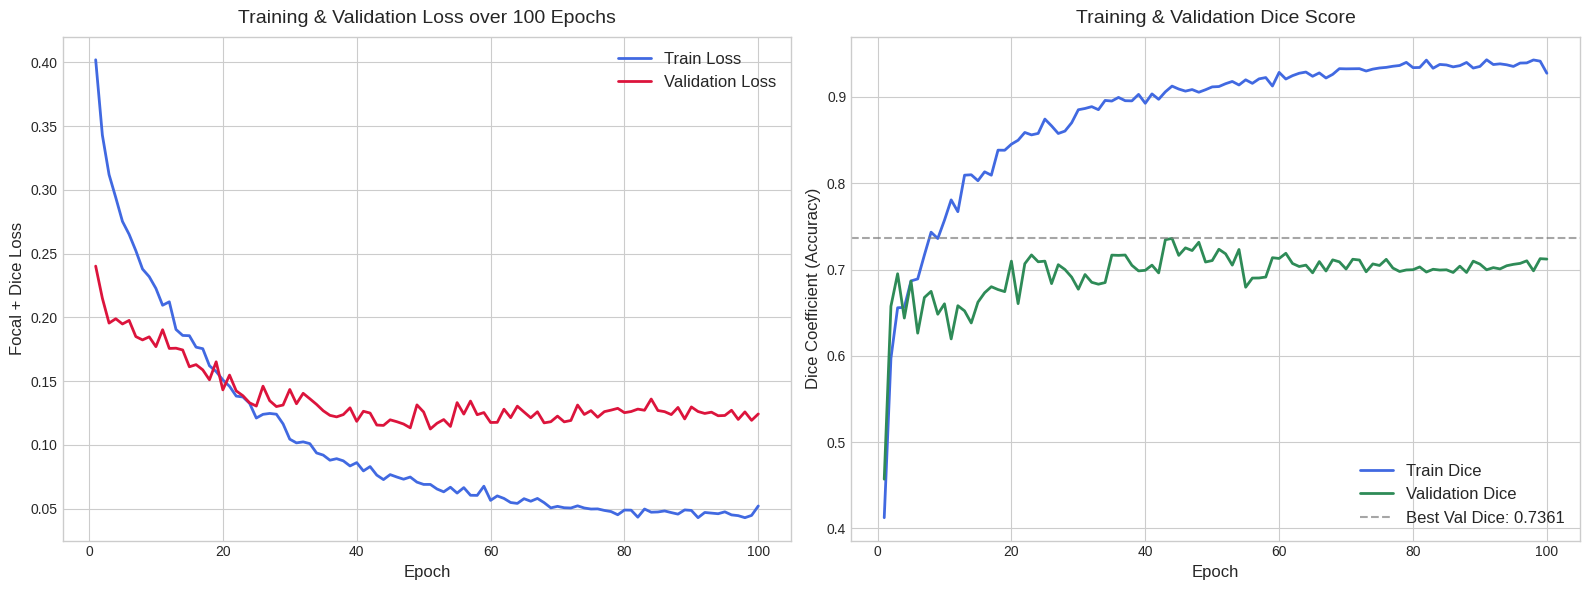

In [10]:
import matplotlib.pyplot as plt
import re

log_text = """
Epoch [001/100] | T-Loss: 0.4021 | T-Dice: 0.4125 || V-Loss: 0.2402 | V-Dice: 0.4571
Epoch [002/100] | T-Loss: 0.3430 | T-Dice: 0.5971 || V-Loss: 0.2150 | V-Dice: 0.6575
Epoch [003/100] | T-Loss: 0.3120 | T-Dice: 0.6557 || V-Loss: 0.1955 | V-Dice: 0.6951
Epoch [004/100] | T-Loss: 0.2940 | T-Dice: 0.6562 || V-Loss: 0.1989 | V-Dice: 0.6438
Epoch [005/100] | T-Loss: 0.2753 | T-Dice: 0.6868 || V-Loss: 0.1948 | V-Dice: 0.6866
Epoch [006/100] | T-Loss: 0.2651 | T-Dice: 0.6891 || V-Loss: 0.1976 | V-Dice: 0.6263
Epoch [007/100] | T-Loss: 0.2523 | T-Dice: 0.7168 || V-Loss: 0.1849 | V-Dice: 0.6676
Epoch [008/100] | T-Loss: 0.2379 | T-Dice: 0.7433 || V-Loss: 0.1823 | V-Dice: 0.6747
Epoch [009/100] | T-Loss: 0.2319 | T-Dice: 0.7359 || V-Loss: 0.1847 | V-Dice: 0.6482
Epoch [010/100] | T-Loss: 0.2227 | T-Dice: 0.7572 || V-Loss: 0.1770 | V-Dice: 0.6603
Epoch [011/100] | T-Loss: 0.2095 | T-Dice: 0.7807 || V-Loss: 0.1903 | V-Dice: 0.6196
Epoch [012/100] | T-Loss: 0.2122 | T-Dice: 0.7670 || V-Loss: 0.1756 | V-Dice: 0.6581
Epoch [013/100] | T-Loss: 0.1905 | T-Dice: 0.8093 || V-Loss: 0.1758 | V-Dice: 0.6521
Epoch [014/100] | T-Loss: 0.1858 | T-Dice: 0.8098 || V-Loss: 0.1744 | V-Dice: 0.6381
Epoch [015/100] | T-Loss: 0.1856 | T-Dice: 0.8029 || V-Loss: 0.1612 | V-Dice: 0.6622
Epoch [016/100] | T-Loss: 0.1766 | T-Dice: 0.8132 || V-Loss: 0.1629 | V-Dice: 0.6731
Epoch [017/100] | T-Loss: 0.1754 | T-Dice: 0.8093 || V-Loss: 0.1588 | V-Dice: 0.6801
Epoch [018/100] | T-Loss: 0.1620 | T-Dice: 0.8383 || V-Loss: 0.1510 | V-Dice: 0.6768
Epoch [019/100] | T-Loss: 0.1575 | T-Dice: 0.8382 || V-Loss: 0.1651 | V-Dice: 0.6744
Epoch [020/100] | T-Loss: 0.1509 | T-Dice: 0.8452 || V-Loss: 0.1431 | V-Dice: 0.7097
Epoch [021/100] | T-Loss: 0.1459 | T-Dice: 0.8498 || V-Loss: 0.1547 | V-Dice: 0.6605
Epoch [022/100] | T-Loss: 0.1382 | T-Dice: 0.8588 || V-Loss: 0.1423 | V-Dice: 0.7067
Epoch [023/100] | T-Loss: 0.1375 | T-Dice: 0.8560 || V-Loss: 0.1385 | V-Dice: 0.7169
Epoch [024/100] | T-Loss: 0.1325 | T-Dice: 0.8577 || V-Loss: 0.1329 | V-Dice: 0.7090
Epoch [025/100] | T-Loss: 0.1210 | T-Dice: 0.8743 || V-Loss: 0.1304 | V-Dice: 0.7097
Epoch [026/100] | T-Loss: 0.1239 | T-Dice: 0.8664 || V-Loss: 0.1460 | V-Dice: 0.6837
Epoch [027/100] | T-Loss: 0.1246 | T-Dice: 0.8576 || V-Loss: 0.1346 | V-Dice: 0.7056
Epoch [028/100] | T-Loss: 0.1240 | T-Dice: 0.8604 || V-Loss: 0.1300 | V-Dice: 0.7000
Epoch [029/100] | T-Loss: 0.1164 | T-Dice: 0.8700 || V-Loss: 0.1312 | V-Dice: 0.6912
Epoch [030/100] | T-Loss: 0.1044 | T-Dice: 0.8851 || V-Loss: 0.1434 | V-Dice: 0.6772
Epoch [031/100] | T-Loss: 0.1015 | T-Dice: 0.8866 || V-Loss: 0.1322 | V-Dice: 0.6942
Epoch [032/100] | T-Loss: 0.1023 | T-Dice: 0.8887 || V-Loss: 0.1404 | V-Dice: 0.6852
Epoch [033/100] | T-Loss: 0.1009 | T-Dice: 0.8852 || V-Loss: 0.1361 | V-Dice: 0.6830
Epoch [034/100] | T-Loss: 0.0936 | T-Dice: 0.8959 || V-Loss: 0.1317 | V-Dice: 0.6849
Epoch [035/100] | T-Loss: 0.0919 | T-Dice: 0.8952 || V-Loss: 0.1267 | V-Dice: 0.7167
Epoch [036/100] | T-Loss: 0.0879 | T-Dice: 0.8994 || V-Loss: 0.1231 | V-Dice: 0.7164
Epoch [037/100] | T-Loss: 0.0891 | T-Dice: 0.8956 || V-Loss: 0.1219 | V-Dice: 0.7168
Epoch [038/100] | T-Loss: 0.0874 | T-Dice: 0.8954 || V-Loss: 0.1237 | V-Dice: 0.7049
Epoch [039/100] | T-Loss: 0.0834 | T-Dice: 0.9029 || V-Loss: 0.1290 | V-Dice: 0.6984
Epoch [040/100] | T-Loss: 0.0860 | T-Dice: 0.8926 || V-Loss: 0.1184 | V-Dice: 0.6991
Epoch [041/100] | T-Loss: 0.0795 | T-Dice: 0.9035 || V-Loss: 0.1263 | V-Dice: 0.7051
Epoch [042/100] | T-Loss: 0.0829 | T-Dice: 0.8972 || V-Loss: 0.1249 | V-Dice: 0.6961
Epoch [043/100] | T-Loss: 0.0762 | T-Dice: 0.9059 || V-Loss: 0.1155 | V-Dice: 0.7345
Epoch [044/100] | T-Loss: 0.0727 | T-Dice: 0.9125 || V-Loss: 0.1152 | V-Dice: 0.7361
Epoch [045/100] | T-Loss: 0.0766 | T-Dice: 0.9091 || V-Loss: 0.1196 | V-Dice: 0.7164
Epoch [046/100] | T-Loss: 0.0747 | T-Dice: 0.9067 || V-Loss: 0.1181 | V-Dice: 0.7251
Epoch [047/100] | T-Loss: 0.0730 | T-Dice: 0.9085 || V-Loss: 0.1163 | V-Dice: 0.7220
Epoch [048/100] | T-Loss: 0.0747 | T-Dice: 0.9054 || V-Loss: 0.1133 | V-Dice: 0.7316
Epoch [049/100] | T-Loss: 0.0707 | T-Dice: 0.9083 || V-Loss: 0.1313 | V-Dice: 0.7087
Epoch [050/100] | T-Loss: 0.0689 | T-Dice: 0.9116 || V-Loss: 0.1257 | V-Dice: 0.7104
Epoch [051/100] | T-Loss: 0.0689 | T-Dice: 0.9120 || V-Loss: 0.1124 | V-Dice: 0.7235
Epoch [052/100] | T-Loss: 0.0653 | T-Dice: 0.9153 || V-Loss: 0.1169 | V-Dice: 0.7182
Epoch [053/100] | T-Loss: 0.0631 | T-Dice: 0.9179 || V-Loss: 0.1198 | V-Dice: 0.7051
Epoch [054/100] | T-Loss: 0.0667 | T-Dice: 0.9138 || V-Loss: 0.1144 | V-Dice: 0.7232
Epoch [055/100] | T-Loss: 0.0621 | T-Dice: 0.9198 || V-Loss: 0.1331 | V-Dice: 0.6795
Epoch [056/100] | T-Loss: 0.0664 | T-Dice: 0.9157 || V-Loss: 0.1241 | V-Dice: 0.6901
Epoch [057/100] | T-Loss: 0.0604 | T-Dice: 0.9209 || V-Loss: 0.1343 | V-Dice: 0.6902
Epoch [058/100] | T-Loss: 0.0603 | T-Dice: 0.9224 || V-Loss: 0.1236 | V-Dice: 0.6913
Epoch [059/100] | T-Loss: 0.0675 | T-Dice: 0.9126 || V-Loss: 0.1253 | V-Dice: 0.7137
Epoch [060/100] | T-Loss: 0.0564 | T-Dice: 0.9284 || V-Loss: 0.1175 | V-Dice: 0.7128
Epoch [061/100] | T-Loss: 0.0599 | T-Dice: 0.9207 || V-Loss: 0.1176 | V-Dice: 0.7188
Epoch [062/100] | T-Loss: 0.0579 | T-Dice: 0.9246 || V-Loss: 0.1279 | V-Dice: 0.7070
Epoch [063/100] | T-Loss: 0.0547 | T-Dice: 0.9274 || V-Loss: 0.1213 | V-Dice: 0.7035
Epoch [064/100] | T-Loss: 0.0540 | T-Dice: 0.9288 || V-Loss: 0.1303 | V-Dice: 0.7051
Epoch [065/100] | T-Loss: 0.0577 | T-Dice: 0.9239 || V-Loss: 0.1257 | V-Dice: 0.6962
Epoch [066/100] | T-Loss: 0.0557 | T-Dice: 0.9278 || V-Loss: 0.1212 | V-Dice: 0.7092
Epoch [067/100] | T-Loss: 0.0579 | T-Dice: 0.9219 || V-Loss: 0.1259 | V-Dice: 0.6983
Epoch [068/100] | T-Loss: 0.0546 | T-Dice: 0.9261 || V-Loss: 0.1172 | V-Dice: 0.7112
Epoch [069/100] | T-Loss: 0.0505 | T-Dice: 0.9327 || V-Loss: 0.1181 | V-Dice: 0.7089
Epoch [070/100] | T-Loss: 0.0517 | T-Dice: 0.9325 || V-Loss: 0.1225 | V-Dice: 0.7006
Epoch [071/100] | T-Loss: 0.0506 | T-Dice: 0.9326 || V-Loss: 0.1180 | V-Dice: 0.7119
Epoch [072/100] | T-Loss: 0.0504 | T-Dice: 0.9327 || V-Loss: 0.1191 | V-Dice: 0.7110
Epoch [073/100] | T-Loss: 0.0521 | T-Dice: 0.9300 || V-Loss: 0.1312 | V-Dice: 0.6974
Epoch [074/100] | T-Loss: 0.0504 | T-Dice: 0.9322 || V-Loss: 0.1238 | V-Dice: 0.7065
Epoch [075/100] | T-Loss: 0.0496 | T-Dice: 0.9335 || V-Loss: 0.1268 | V-Dice: 0.7047
Epoch [076/100] | T-Loss: 0.0497 | T-Dice: 0.9342 || V-Loss: 0.1216 | V-Dice: 0.7118
Epoch [077/100] | T-Loss: 0.0485 | T-Dice: 0.9355 || V-Loss: 0.1260 | V-Dice: 0.7017
Epoch [078/100] | T-Loss: 0.0476 | T-Dice: 0.9364 || V-Loss: 0.1272 | V-Dice: 0.6977
Epoch [079/100] | T-Loss: 0.0451 | T-Dice: 0.9400 || V-Loss: 0.1286 | V-Dice: 0.6995
Epoch [080/100] | T-Loss: 0.0488 | T-Dice: 0.9339 || V-Loss: 0.1252 | V-Dice: 0.6998
Epoch [081/100] | T-Loss: 0.0487 | T-Dice: 0.9341 || V-Loss: 0.1261 | V-Dice: 0.7030
Epoch [082/100] | T-Loss: 0.0432 | T-Dice: 0.9426 || V-Loss: 0.1280 | V-Dice: 0.6971
Epoch [083/100] | T-Loss: 0.0496 | T-Dice: 0.9332 || V-Loss: 0.1271 | V-Dice: 0.7003
Epoch [084/100] | T-Loss: 0.0471 | T-Dice: 0.9376 || V-Loss: 0.1359 | V-Dice: 0.6994
Epoch [085/100] | T-Loss: 0.0473 | T-Dice: 0.9370 || V-Loss: 0.1269 | V-Dice: 0.6997
Epoch [086/100] | T-Loss: 0.0481 | T-Dice: 0.9348 || V-Loss: 0.1260 | V-Dice: 0.6966
Epoch [087/100] | T-Loss: 0.0468 | T-Dice: 0.9362 || V-Loss: 0.1237 | V-Dice: 0.7039
Epoch [088/100] | T-Loss: 0.0456 | T-Dice: 0.9399 || V-Loss: 0.1293 | V-Dice: 0.6966
Epoch [089/100] | T-Loss: 0.0489 | T-Dice: 0.9334 || V-Loss: 0.1203 | V-Dice: 0.7097
Epoch [090/100] | T-Loss: 0.0485 | T-Dice: 0.9353 || V-Loss: 0.1297 | V-Dice: 0.7063
Epoch [091/100] | T-Loss: 0.0428 | T-Dice: 0.9430 || V-Loss: 0.1261 | V-Dice: 0.6997
Epoch [092/100] | T-Loss: 0.0469 | T-Dice: 0.9375 || V-Loss: 0.1246 | V-Dice: 0.7022
Epoch [093/100] | T-Loss: 0.0464 | T-Dice: 0.9383 || V-Loss: 0.1256 | V-Dice: 0.7007
Epoch [094/100] | T-Loss: 0.0459 | T-Dice: 0.9372 || V-Loss: 0.1228 | V-Dice: 0.7044
Epoch [095/100] | T-Loss: 0.0474 | T-Dice: 0.9353 || V-Loss: 0.1230 | V-Dice: 0.7060
Epoch [096/100] | T-Loss: 0.0450 | T-Dice: 0.9392 || V-Loss: 0.1271 | V-Dice: 0.7071
Epoch [097/100] | T-Loss: 0.0444 | T-Dice: 0.9394 || V-Loss: 0.1199 | V-Dice: 0.7101
Epoch [098/100] | T-Loss: 0.0428 | T-Dice: 0.9428 || V-Loss: 0.1258 | V-Dice: 0.6985
Epoch [099/100] | T-Loss: 0.0446 | T-Dice: 0.9414 || V-Loss: 0.1192 | V-Dice: 0.7126
Epoch [100/100] | T-Loss: 0.0520 | T-Dice: 0.9274 || V-Loss: 0.1242 | V-Dice: 0.7121



"""


epochs = []
train_loss, train_dice = [], []
val_loss, val_dice = [], []

pattern = r"Epoch \[(\d+)/\d+\] \| T-Loss: ([\d.]+) \| T-Dice: ([\d.]+) \|\| V-Loss: ([\d.]+) \| V-Dice: ([\d.]+)"

for match in re.finditer(pattern, log_text):
    epochs.append(int(match.group(1)))
    train_loss.append(float(match.group(2)))
    train_dice.append(float(match.group(3)))
    val_loss.append(float(match.group(4)))
    val_dice.append(float(match.group(5)))

plt.figure(figsize=(16, 6))
plt.style.use('seaborn-v0_8-whitegrid')

plt.subplot(1, 2, 1)
plt.plot(epochs, train_loss, label='Train Loss', color='royalblue', linewidth=2)
plt.plot(epochs, val_loss, label='Validation Loss', color='crimson', linewidth=2)
plt.title('Training & Validation Loss over 100 Epochs', fontsize=14, pad=10)
plt.xlabel('Epoch', fontsize=12)
plt.ylabel('Focal + Dice Loss', fontsize=12)
plt.legend(fontsize=12)

plt.subplot(1, 2, 2)
plt.plot(epochs, train_dice, label='Train Dice', color='royalblue', linewidth=2)
plt.plot(epochs, val_dice, label='Validation Dice', color='seagreen', linewidth=2)
plt.axhline(y=max(val_dice), color='gray', linestyle='--', alpha=0.7, label=f'Best Val Dice: {max(val_dice):.4f}')
plt.title('Training & Validation Dice Score', fontsize=14, pad=10)
plt.xlabel('Epoch', fontsize=12)
plt.ylabel('Dice Coefficient (Accuracy)', fontsize=12)
plt.legend(fontsize=12)

plt.tight_layout()
plt.show()